# 🎙️ Deepfake Voice Detection — Wav2Vec2 Custom Branch

**What this notebook does:**
- Step 1: Pure PyTorch pipeline (replaces TF/Keras custom model)
- Step 2: Wav2Vec2 encoder (frozen) + trainable classifier head
- Step 3: Temporal attention pooling (replaces mean pooling, visualizable)
- Trains on ASVspoof 2019 LA dataset (mounted from Kaggle)
- Saves weights to your HuggingFace Hub repo
- Generates all required training graphs


## 0. Install & Imports

In [42]:
# Install required packages (transformers + huggingface hub)
!pip install -q transformers huggingface_hub torchaudio librosa matplotlib seaborn scikit-learn

In [43]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T

from transformers import Wav2Vec2Model, Wav2Vec2Processor
from huggingface_hub import HfApi, login, create_repo

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {DEVICE}")
print(f"CUDA devices : {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Device       : cuda
CUDA devices : 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 1. Configuration
> ✏️ **Edit `HF_TOKEN` and `HF_REPO_ID` before running**

In [44]:
from kaggle_secrets import UserSecretsClient

# Load token securely from Kaggle Secrets
secrets = UserSecretsClient()
HF_TOKEN = secrets.get_secret("HF_TOKEN")

# Hugging Face repo
HF_REPO_ID = "IshatShivhare/deepfake-voice-wav2vec2"

# Dataset path on Kaggle (after adding the ASVspoof 2019 dataset)
DATA_ROOT     = "/kaggle/input/datasets/anishsarkar22/asvpoof-2019-dataset-la"
LA_ROOT       = os.path.join(DATA_ROOT, "LA")

# ─────────────────────────────────────────────────────────────────────────────
#  TRAINING HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
CFG = dict(
    sample_rate        = 16000,
    max_audio_len_sec  = 4.0,       # clip/pad all audio to this length
    batch_size         = 64,
    num_workers        = 4,
    lr_head            = 2e-3,      # classifier head learning rate
    lr_encoder         = 1e-5,      # encoder fine-tune LR (used in phase 2)
    epochs_phase1      = 10,        # frozen encoder, train head only
    epochs_phase2      = 5,         # unfreeze last 3 layers, fine-tune
    dropout            = 0.3,
    hidden_dim         = 256,
    attn_dim           = 128,       # temporal attention projection dim
    wav2vec_model      = "facebook/wav2vec2-base",
    checkpoint_dir     = "/kaggle/working/checkpoints",
    output_dir         = "/kaggle/working/outputs",
    accumulation_steps = 2,
)

os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
os.makedirs(CFG["output_dir"], exist_ok=True)
os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
os.makedirs(CFG["output_dir"], exist_ok=True)

# ── HuggingFace early init (needed during training for resume checkpoints) ────
login(token=HF_TOKEN)
api = HfApi()
try:
    create_repo(HF_REPO_ID, token=HF_TOKEN, private=False, exist_ok=True)
    print(f"HF repo ready: https://huggingface.co/{HF_REPO_ID}")
except Exception as e:
    print(f"Repo note: {e}")

print("Config ready ✓")
print(json.dumps(CFG, indent=2))

HF repo ready: https://huggingface.co/IshatShivhare/deepfake-voice-wav2vec2
Config ready ✓
{
  "sample_rate": 16000,
  "max_audio_len_sec": 4.0,
  "batch_size": 64,
  "num_workers": 4,
  "lr_head": 0.002,
  "lr_encoder": 1e-05,
  "epochs_phase1": 10,
  "epochs_phase2": 5,
  "dropout": 0.3,
  "hidden_dim": 256,
  "attn_dim": 128,
  "wav2vec_model": "facebook/wav2vec2-base",
  "checkpoint_dir": "/kaggle/working/checkpoints",
  "output_dir": "/kaggle/working/outputs",
  "accumulation_steps": 2
}


## 2. Dataset — ASVspoof 2019 LA

In [45]:
def parse_protocol(protocol_path):
    """
    Parse ASVspoof 2019 LA protocol file.
    Returns a DataFrame with columns: speaker, file, system, label (0=bonafide, 1=spoof)
    """
    rows = []
    with open(protocol_path) as f:
        for line in f:
            parts = line.strip().split()
            # format: SPEAKER FILE - SYSTEM LABEL
            speaker = parts[0]
            fname   = parts[1]
            system  = parts[3]
            label   = 0 if parts[4] == "bonafide" else 1
            rows.append({"speaker": speaker, "file": fname,
                         "system": system, "label": label})
    return pd.DataFrame(rows)


# ── Load protocols ────────────────────────────────────────────────────────────
proto_dir = os.path.join(LA_ROOT, "ASVspoof2019_LA_cm_protocols")

train_df = parse_protocol(os.path.join(proto_dir, "ASVspoof2019.LA.cm.train.trn.txt"))
dev_df   = parse_protocol(os.path.join(proto_dir, "ASVspoof2019.LA.cm.dev.trl.txt"))
eval_df  = parse_protocol(os.path.join(proto_dir, "ASVspoof2019.LA.cm.eval.trl.txt"))

# ── Audio directories ─────────────────────────────────────────────────────────
train_audio = os.path.join(LA_ROOT, "ASVspoof2019_LA_train", "flac")
dev_audio   = os.path.join(LA_ROOT, "ASVspoof2019_LA_dev",   "flac")
eval_audio  = os.path.join(LA_ROOT, "ASVspoof2019_LA_eval",  "flac")

print(f"Train: {len(train_df):,} samples  "
      f"({train_df.label.sum():,} spoof / {(train_df.label==0).sum():,} real)")
print(f"Dev  : {len(dev_df):,} samples")
print(f"Eval : {len(eval_df):,} samples")

Train: 25,380 samples  (22,800 spoof / 2,580 real)
Dev  : 24,844 samples
Eval : 71,237 samples


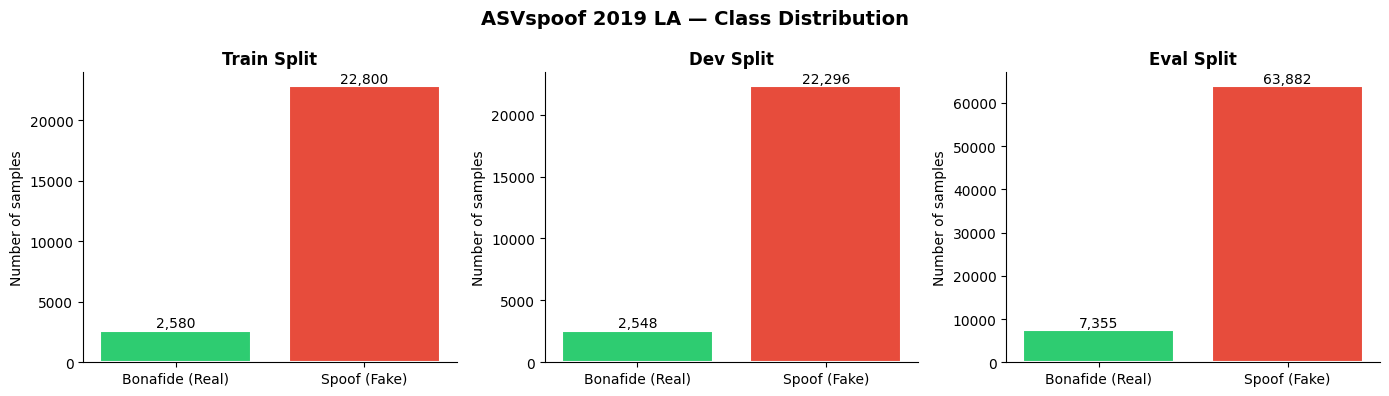

In [46]:
# ── Dataset class distribution plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("ASVspoof 2019 LA — Class Distribution", fontsize=14, fontweight="bold")

for ax, (df, title) in zip(axes, [(train_df, "Train"), (dev_df, "Dev"), (eval_df, "Eval")]):
    counts = df["label"].value_counts().sort_index()
    bars = ax.bar(["Bonafide (Real)", "Spoof (Fake)"], counts.values,
                  color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
    ax.set_title(f"{title} Split", fontweight="bold")
    ax.set_ylabel("Number of samples")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

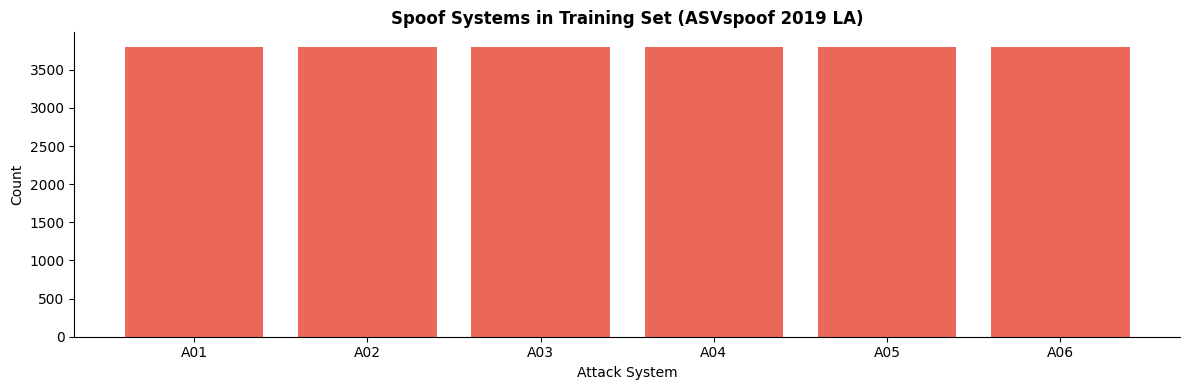

In [47]:
# ── Spoof system distribution (train set only) ────────────────────────────────
spoof_counts = train_df[train_df.label==1]["system"].value_counts()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(spoof_counts.index, spoof_counts.values, color="#e74c3c", alpha=0.85)
ax.set_title("Spoof Systems in Training Set (ASVspoof 2019 LA)", fontweight="bold")
ax.set_xlabel("Attack System")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/spoof_systems.png", dpi=150, bbox_inches="tight")
plt.show()

In [48]:
MAX_LEN = int(CFG["sample_rate"] * CFG["max_audio_len_sec"])

class ASVspoofDataset(Dataset):
    def __init__(self, df, audio_dir, processor, max_len=MAX_LEN):
        self.df        = df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.processor = processor
        self.max_len   = max_len
        self.sr        = CFG["sample_rate"]

    def __len__(self):
        return len(self.df)

    def _load_audio(self, fname):
        path = os.path.join(self.audio_dir, fname + ".flac")
        wav, sr = torchaudio.load(path)
        # Mono
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        # Resample if needed
        if sr != self.sr:
            wav = T.Resample(sr, self.sr)(wav)
        wav = wav.squeeze(0)  # [T]
        # Pad or clip
        if wav.shape[0] < self.max_len:
            wav = F.pad(wav, (0, self.max_len - wav.shape[0]))
        else:
            wav = wav[:self.max_len]
        return wav.numpy()

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        wav  = self._load_audio(row["file"])
        inp  = self.processor(
            wav, sampling_rate=self.sr,
            return_tensors="pt", padding=False
        )
        return (
            inp.input_values.squeeze(0),   # [T]
            torch.tensor(row["label"], dtype=torch.float32)
        )

print("Dataset class defined ✓")

Dataset class defined ✓


## 3. Model Architecture
### Step 2: Wav2Vec2 + Classifier Head
### Step 3: Temporal Attention Pooling

In [49]:
class TemporalAttentionPool(nn.Module):
    """
    Step 3 — Temporal Attention Pooling
    Learns WHICH time steps are suspicious, instead of blindly averaging.
    Returns both the pooled vector and the attention weights (for visualization).
    """
    def __init__(self, hidden_size: int, attn_dim: int):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, attn_dim),
            nn.Tanh(),
            nn.Linear(attn_dim, 1, bias=False),
        )

    def forward(self, hidden_states: torch.Tensor):
        # hidden_states : [B, T, H]
        scores  = self.attn(hidden_states)           # [B, T, 1]
        weights = torch.softmax(scores, dim=1)       # [B, T, 1]
        pooled  = (hidden_states * weights).sum(dim=1)  # [B, H]
        return pooled, weights.squeeze(-1)           # [B, H], [B, T]


class Wav2Vec2Classifier(nn.Module):
    """
    Step 1+2+3 combined:
    - Pure PyTorch (Step 1)
    - Wav2Vec2 encoder with frozen/unfrozen support (Step 2)
    - Temporal attention pooling instead of mean pool (Step 3)
    
    Maps to: src/models/custom/ in your project
    """
    def __init__(self, wav2vec2_name: str, hidden_dim: int,
                 attn_dim: int, dropout: float, freeze_encoder: bool = True):
        super().__init__()

        # ── Encoder ─────────────────────────────────────────────────────────
        self.encoder = Wav2Vec2Model.from_pretrained(wav2vec2_name)
        encoder_dim  = self.encoder.config.hidden_size  # 768 for wav2vec2-base

        if freeze_encoder:
            self.freeze_encoder()

        # ── Temporal Attention Pool (Step 3) ─────────────────────────────────
        self.attn_pool = TemporalAttentionPool(encoder_dim, attn_dim)

        # ── Classifier Head ──────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.LayerNorm(encoder_dim),
            nn.Linear(encoder_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, 1),
        )

    # ── Freeze / Unfreeze helpers ─────────────────────────────────────────────
    def freeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = False

    def unfreeze_last_n_layers(self, n: int = 3):
        """Unfreeze the last n transformer blocks for fine-tuning (Phase 2)."""
        # Keep feature extractor frozen always
        for param in self.encoder.feature_extractor.parameters():
            param.requires_grad = False
        total = len(self.encoder.encoder.layers)
        for i, layer in enumerate(self.encoder.encoder.layers):
            if i >= total - n:
                for param in layer.parameters():
                    param.requires_grad = True
        print(f"Unfroze last {n}/{total} transformer layers")

    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_params(self):
        return sum(p.numel() for p in self.parameters())

    # ── Forward ───────────────────────────────────────────────────────────────
    def forward(self, input_values: torch.Tensor):
        # input_values : [B, T]
        outputs      = self.encoder(input_values)
        hidden       = outputs.last_hidden_state        # [B, T', 768]
        pooled, attn = self.attn_pool(hidden)           # [B, 768], [B, T']
        logit        = self.classifier(pooled)          # [B, 1]
        return logit.squeeze(-1), attn                  # [B], [B, T']


print("Model class defined ✓")

Model class defined ✓


In [50]:
# ── Load processor & instantiate model ───────────────────────────────────────
processor = Wav2Vec2Processor.from_pretrained(CFG["wav2vec_model"])

model = Wav2Vec2Classifier(
    wav2vec2_name = CFG["wav2vec_model"],
    hidden_dim    = CFG["hidden_dim"],
    attn_dim      = CFG["attn_dim"],
    dropout       = CFG["dropout"],
    freeze_encoder= True,
).to(DEVICE)

# Use DataParallel if 2 GPUs available
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    print(f"Using DataParallel across {torch.cuda.device_count()} GPUs")

core = model.module if isinstance(model, nn.DataParallel) else model
print(f"Trainable params : {core.trainable_params():,}")
print(f"Total params     : {core.total_params():,}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using DataParallel across 2 GPUs
Trainable params : 329,985
Total params     : 94,701,697


## 4. DataLoaders

In [51]:
train_ds = ASVspoofDataset(train_df, train_audio, processor)
dev_ds   = ASVspoofDataset(dev_df,   dev_audio,   processor)
eval_ds  = ASVspoofDataset(eval_df,  eval_audio,  processor)

# ── Weighted sampler to handle class imbalance ────────────────────────────────
labels      = train_df["label"].values
class_count = np.bincount(labels)
weights     = 1.0 / class_count[labels]
sampler     = torch.utils.data.WeightedRandomSampler(
    weights, num_samples=len(weights), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          sampler=sampler, num_workers=CFG["num_workers"],
                          pin_memory=True, persistent_workers=True)
dev_loader   = DataLoader(dev_ds,   batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"],
                          pin_memory=True, persistent_workers=True)
eval_loader  = DataLoader(eval_ds,  batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"],
                          pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Dev batches   : {len(dev_loader)}")
print(f"Eval batches  : {len(eval_loader)}")

Train batches : 397
Dev batches   : 389
Eval batches  : 1114


## 5. Training Utilities

In [52]:
def compute_eer(labels, scores):
    """
    Equal Error Rate — the standard metric in anti-spoofing.
    Lower is better. 0% = perfect, 50% = random.
    """
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[idx] + fnr[idx]) / 2, thresholds[idx]


def run_epoch(model, loader, criterion, optimizer=None, train=True, accumulation_steps=2):
    model.train() if train else model.eval()
    total_loss, all_labels, all_scores = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for i, (x, y) in enumerate(loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, _ = model(x)
            
            # 1. Scale loss by accumulation steps
            loss = criterion(logits, y) / accumulation_steps
            
            if train and optimizer:
                loss.backward()
                
                # 2. Only update weights after 'accumulation_steps' batches
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(loader):
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    optimizer.zero_grad()

            total_loss += loss.item() * accumulation_steps # Restore loss for logging
            all_labels.extend(y.cpu().numpy())
            all_scores.extend(torch.sigmoid(logits).detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc      = roc_auc_score(all_labels, all_scores)
    eer, _   = compute_eer(np.array(all_labels), np.array(all_scores))
    acc      = ((np.array(all_scores) > 0.5) == np.array(all_labels)).mean()
    return avg_loss, auc, eer, acc


print("Training utilities defined ✓")

Training utilities defined ✓


In [53]:
# ── HuggingFace resume helpers ────────────────────────────────────────────────
def push_resume_to_hf(local_path, phase_name):
    """Upload resume checkpoint to HuggingFace Hub after every epoch."""
    try:
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=f"checkpoints/resume_{phase_name}.pth",
            repo_id=HF_REPO_ID,
            token=HF_TOKEN,
        )
    except Exception as e:
        print(f"  ⚠️ HF upload failed (non-fatal): {e}")


def pull_resume_from_hf(local_path, phase_name):
    from huggingface_hub import hf_hub_download
    import shutil
    try:
        downloaded = hf_hub_download(
            repo_id=HF_REPO_ID,
            filename=f"checkpoints/resume_{phase_name}.pth",
            token=HF_TOKEN,
        )
        print(f"  Downloaded to: {downloaded}")        # ← where HF saved it
        print(f"  Copying to   : {local_path}")        # ← where we need it
        shutil.copy(downloaded, local_path)
        print(f"  File exists after copy: {os.path.exists(local_path)}")  # ← confirm
        print(f"⚡ Resume checkpoint pulled from HF for {phase_name}")
        return True
    except Exception as e:
        print(f"No remote resume checkpoint found for {phase_name} — fresh start.")
        print(f"  Error: {e}")                         # ← see actual error
        return False


def train_phase(model, train_loader, dev_loader, optimizer, scheduler,
                criterion, epochs, phase_name, history):
    best_ckpt   = os.path.join(CFG["checkpoint_dir"], f"best_{phase_name}.pth")
    resume_ckpt = os.path.join(CFG["checkpoint_dir"], f"resume_{phase_name}.pth")

    # ── Pull from HF if no local checkpoint exists ────────────────────────────
    if not os.path.exists(resume_ckpt):
        pull_resume_from_hf(resume_ckpt, phase_name)

    # ── Resume logic ──────────────────────────────────────────────────────────
    start_epoch = 1
    best_eer    = float("inf")

    if os.path.exists(resume_ckpt):
        print(f"⚡ Resume checkpoint found for {phase_name} — loading...")
        ckpt = torch.load(resume_ckpt, map_location=DEVICE, weights_only=False)

        core = model.module if isinstance(model, nn.DataParallel) else model
        core.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])

        for k, v in ckpt["history"].items():
            history[k] = v

        best_eer    = ckpt["best_eer"]
        start_epoch = ckpt["epoch"] + 1

        print(f"  ↳ Resuming from epoch {ckpt['epoch']}/{epochs} "
              f"| Best EER so far: {best_eer*100:.2f}%")

        if start_epoch > epochs:
            print(f"  ✓ {phase_name} already fully completed — skipping.")
            return history, best_ckpt
    else:
        print(f"No resume checkpoint found — starting {phase_name} from epoch 1.")

    print("=" * 65)

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(start_epoch, epochs + 1):
        tr_loss, tr_auc, tr_eer, tr_acc = run_epoch(
            model, train_loader, criterion, optimizer, train=True)
        dv_loss, dv_auc, dv_eer, dv_acc = run_epoch(
            model, dev_loader, criterion, train=False)

        scheduler.step(dv_loss)

        history["train_loss"].append(tr_loss)
        history["dev_loss"].append(dv_loss)
        history["train_auc"].append(tr_auc)
        history["dev_auc"].append(dv_auc)
        history["train_eer"].append(tr_eer)
        history["dev_eer"].append(dv_eer)
        history["train_acc"].append(tr_acc)
        history["dev_acc"].append(dv_acc)
        history["phase"].append(phase_name)

        print(f"[{phase_name}] Ep {epoch:02d}/{epochs} | "
              f"Loss {tr_loss:.4f}/{dv_loss:.4f} | "
              f"AUC {tr_auc:.4f}/{dv_auc:.4f} | "
              f"EER {tr_eer*100:.2f}%/{dv_eer*100:.2f}% | "
              f"Acc {tr_acc*100:.1f}%/{dv_acc*100:.1f}%")

# ── Save best weights checkpoint ──────────────────────────────────────
        if dv_eer < best_eer:
            best_eer = dv_eer
            core = model.module if isinstance(model, nn.DataParallel) else model
            torch.save(core.state_dict(), best_ckpt)
            print(f"  ✓ Best EER {best_eer*100:.2f}% — best checkpoint saved")
            # ── Also push best checkpoint to HF ──────────────────────────────
            try:
                api.upload_file(
                    path_or_fileobj=best_ckpt,
                    path_in_repo=f"checkpoints/best_{phase_name}.pth",
                    repo_id=HF_REPO_ID,
                    token=HF_TOKEN,
                )
                print(f"  ✓ Best checkpoint pushed to HF")
            except Exception as e:
                print(f"  ⚠️ HF best checkpoint upload failed (non-fatal): {e}")

        # ── Save full resume checkpoint locally ───────────────────────────────
        core = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({
            "epoch"          : epoch,
            "model_state"    : core.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history"        : dict(history),
            "best_eer"       : best_eer,
        }, resume_ckpt)

        # ── Push resume checkpoint to HF after every epoch ───────────────────
        push_resume_to_hf(resume_ckpt, phase_name)

    return history, best_ckpt

## 6. Phase 1 — Train Classifier Head (Encoder Frozen)

In [54]:
criterion = nn.BCEWithLogitsLoss()

# Only optimize classifier head + attention pool (encoder frozen)
core = model.module if isinstance(model, nn.DataParallel) else model
phase1_params = list(core.attn_pool.parameters()) + list(core.classifier.parameters())

optimizer_p1 = torch.optim.AdamW(phase1_params, lr=CFG["lr_head"], weight_decay=1e-4)
scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode="min", factor=0.5, patience=2
)

history = defaultdict(list)

print("=" * 65)
print("PHASE 1 — Frozen Encoder, Training Head Only")
print("=" * 65)

history, best_p1 = train_phase(
    model, train_loader, dev_loader,
    optimizer_p1, scheduler_p1, criterion,
    CFG["epochs_phase1"], "phase1", history
)

PHASE 1 — Frozen Encoder, Training Head Only
⚡ Resume checkpoint found for phase1 — loading...
  ↳ Resuming from epoch 10/10 | Best EER so far: 1.02%
  ✓ phase1 already fully completed — skipping.


## 7. Phase 2 — Fine-Tune Last 3 Encoder Layers

In [55]:
# ── Load best phase1 weights, then unfreeze top layers ───────────────────────
core = model.module if isinstance(model, nn.DataParallel) else model

best_p1 = os.path.join(CFG["checkpoint_dir"], "best_phase1.pth")

if not os.path.exists(best_p1):
    print("best_phase1.pth not found — extracting from resume checkpoint...")
    resume_p1 = os.path.join(CFG["checkpoint_dir"], "resume_phase1.pth")

    # Pull resume checkpoint from HF if not local
    if not os.path.exists(resume_p1):
        from huggingface_hub import hf_hub_download
        import shutil
        downloaded = hf_hub_download(
            repo_id=HF_REPO_ID,
            filename="checkpoints/resume_phase1.pth",
            token=HF_TOKEN,
        )
        shutil.copy(downloaded, resume_p1)

    # Extract just the model weights and save as best_phase1.pth
    ckpt = torch.load(resume_p1, map_location=DEVICE, weights_only=False)
    torch.save(ckpt["model_state"], best_p1)
    print(f"  ✓ Extracted best weights (EER: {ckpt['best_eer']*100:.2f}%)")

core.load_state_dict(torch.load(best_p1, weights_only=False))
core.unfreeze_last_n_layers(n=3)

print(f"Trainable params after unfreeze : {core.trainable_params():,}")

# Lower LR for encoder layers to avoid catastrophic forgetting
optimizer_p2 = torch.optim.AdamW([
    {"params": core.encoder.encoder.layers[-3:].parameters(), "lr": CFG["lr_encoder"]},
    {"params": core.attn_pool.parameters(),  "lr": CFG["lr_head"] * 0.1},
    {"params": core.classifier.parameters(), "lr": CFG["lr_head"] * 0.1},
], weight_decay=1e-4)

scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=CFG["epochs_phase2"], eta_min=1e-7
)

print("=" * 65)
print("PHASE 2 — Fine-Tuning Last 3 Encoder Layers")
print("=" * 65)

history, best_p2 = train_phase(
    model, train_loader, dev_loader,
    optimizer_p2, scheduler_p2, criterion,
    CFG["epochs_phase2"], "phase2", history
)

best_phase1.pth not found — extracting from resume checkpoint...
  ✓ Extracted best weights (EER: 1.02%)
Unfroze last 3/12 transformer layers
Trainable params after unfreeze : 21,593,601
PHASE 2 — Fine-Tuning Last 3 Encoder Layers
No remote resume checkpoint found for phase2 — fresh start.
  Error: 404 Client Error. (Request ID: Root=1-69e31357-1a431f43702ab69c01d746f2;7b8a06c7-1685-4e66-9660-b5f3486cac93)

Entry Not Found for url: https://huggingface.co/IshatShivhare/deepfake-voice-wav2vec2/resolve/main/checkpoints/resume_phase2.pth.
No resume checkpoint found — starting phase2 from epoch 1.


/tmp/ipykernel_55/1419940916.py:82: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(dv_loss)


[phase2] Ep 01/5 | Loss 0.0053/0.0086 | AUC 1.0000/0.9996 | EER 0.15%/0.52% | Acc 99.8%/99.8%
  ✓ Best EER 0.52% — best checkpoint saved


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

/tmp/ipykernel_55/1419940916.py:82: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(dv_loss)


[phase2] Ep 05/5 | Loss 0.0015/0.0186 | AUC 1.0000/0.9998 | EER 0.04%/0.42% | Acc 100.0%/99.5%


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

## 8. Training Graphs

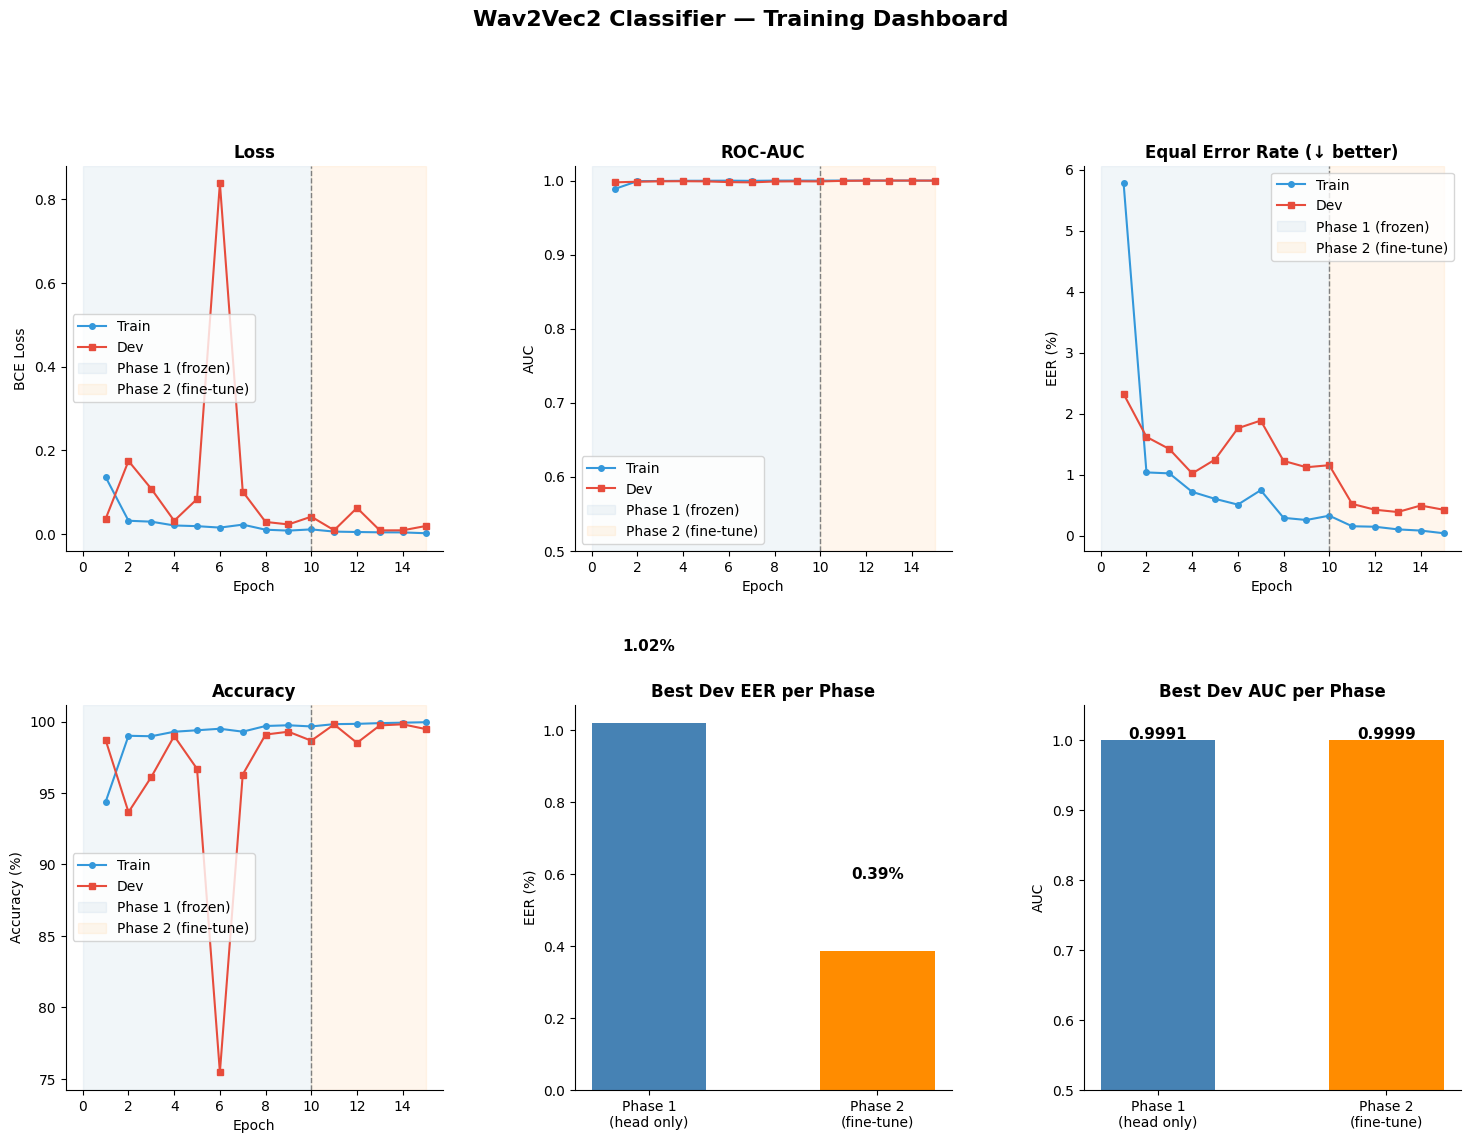

Training dashboard saved ✓


In [56]:
def add_phase_bands(ax, phases):
    """Shade phase 1 vs phase 2 regions on a plot."""
    p1_end = sum(1 for p in phases if p == "phase1")
    ax.axvspan(0, p1_end, alpha=0.07, color="steelblue", label="Phase 1 (frozen)")
    ax.axvspan(p1_end, len(phases), alpha=0.07, color="darkorange", label="Phase 2 (fine-tune)")
    ax.axvline(p1_end, color="gray", linestyle="--", linewidth=1)


epochs_x = list(range(1, len(history["train_loss"]) + 1))

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Wav2Vec2 Classifier — Training Dashboard", fontsize=16, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Loss ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_x, history["train_loss"], label="Train", color="#3498db", marker="o", ms=4)
ax1.plot(epochs_x, history["dev_loss"],   label="Dev",   color="#e74c3c", marker="s", ms=4)
add_phase_bands(ax1, history["phase"])
ax1.set_title("Loss", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.legend(); ax1.spines[["top","right"]].set_visible(False)

# ── 2. AUC ───────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_x, history["train_auc"], label="Train", color="#3498db", marker="o", ms=4)
ax2.plot(epochs_x, history["dev_auc"],   label="Dev",   color="#e74c3c", marker="s", ms=4)
add_phase_bands(ax2, history["phase"])
ax2.set_title("ROC-AUC", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("AUC")
ax2.set_ylim([0.5, 1.02])
ax2.legend(); ax2.spines[["top","right"]].set_visible(False)

# ── 3. EER ───────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs_x, [e*100 for e in history["train_eer"]], label="Train",
         color="#3498db", marker="o", ms=4)
ax3.plot(epochs_x, [e*100 for e in history["dev_eer"]], label="Dev",
         color="#e74c3c", marker="s", ms=4)
add_phase_bands(ax3, history["phase"])
ax3.set_title("Equal Error Rate (↓ better)", fontweight="bold")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("EER (%)")
ax3.legend(); ax3.spines[["top","right"]].set_visible(False)

# ── 4. Accuracy ──────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs_x, [a*100 for a in history["train_acc"]], label="Train",
         color="#3498db", marker="o", ms=4)
ax4.plot(epochs_x, [a*100 for a in history["dev_acc"]], label="Dev",
         color="#e74c3c", marker="s", ms=4)
add_phase_bands(ax4, history["phase"])
ax4.set_title("Accuracy", fontweight="bold")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Accuracy (%)")
ax4.legend(); ax4.spines[["top","right"]].set_visible(False)

# ── 5. Phase comparison bar chart ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
p1_indices = [i for i,p in enumerate(history["phase"]) if p=="phase1"]
p2_indices = [i for i,p in enumerate(history["phase"]) if p=="phase2"]
best_p1_eer = min(history["dev_eer"][i] for i in p1_indices) * 100
best_p2_eer = min(history["dev_eer"][i] for i in p2_indices) * 100 if p2_indices else best_p1_eer
bars = ax5.bar(["Phase 1\n(head only)", "Phase 2\n(fine-tune)"],
               [best_p1_eer, best_p2_eer],
               color=["steelblue", "darkorange"], width=0.5)
for bar, val in zip(bars, [best_p1_eer, best_p2_eer]):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{val:.2f}%", ha="center", fontsize=11, fontweight="bold")
ax5.set_title("Best Dev EER per Phase", fontweight="bold")
ax5.set_ylabel("EER (%)"); ax5.spines[["top","right"]].set_visible(False)

# ── 6. Phase 1 vs 2 AUC gain ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
best_p1_auc = max(history["dev_auc"][i] for i in p1_indices)
best_p2_auc = max(history["dev_auc"][i] for i in p2_indices) if p2_indices else best_p1_auc
bars = ax6.bar(["Phase 1\n(head only)", "Phase 2\n(fine-tune)"],
               [best_p1_auc, best_p2_auc],
               color=["steelblue", "darkorange"], width=0.5)
for bar, val in zip(bars, [best_p1_auc, best_p2_auc]):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax6.set_title("Best Dev AUC per Phase", fontweight="bold")
ax6.set_ylabel("AUC"); ax6.set_ylim([0.5, 1.05])
ax6.spines[["top","right"]].set_visible(False)

plt.savefig(f"{CFG['output_dir']}/training_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training dashboard saved ✓")

## 9. Evaluation on Eval Set + ROC Curve + Confusion Matrix

In [57]:
# Load best weights from Phase 2
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(torch.load(best_p2))
model.eval()

all_labels, all_scores, all_attn = [], [], []

with torch.no_grad():
    for x, y in eval_loader:
        x = x.to(DEVICE)
        logits, attn = model(x)
        scores = torch.sigmoid(logits).cpu().numpy()
        all_labels.extend(y.numpy())
        all_scores.extend(scores)
        all_attn.append(attn.cpu().numpy())

all_labels = np.array(all_labels)
all_scores = np.array(all_scores)
all_preds  = (all_scores > 0.5).astype(int)

final_eer, eer_thresh = compute_eer(all_labels, all_scores)
final_auc = roc_auc_score(all_labels, all_scores)
final_acc = (all_preds == all_labels).mean()

print("=" * 45)
print("  FINAL EVAL SET RESULTS")
print("=" * 45)
print(f"  EER      : {final_eer*100:.2f}%")
print(f"  AUC      : {final_auc:.4f}")
print(f"  Accuracy : {final_acc*100:.2f}%")
print("=" * 45)
print()
print(classification_report(all_labels, all_preds,
                             target_names=["Bonafide", "Spoof"]))

  FINAL EVAL SET RESULTS
  EER      : 1.76%
  AUC      : 0.9984
  Accuracy : 96.16%

              precision    recall  f1-score   support

    Bonafide       0.73      0.99      0.84      7355
       Spoof       1.00      0.96      0.98     63882

    accuracy                           0.96     71237
   macro avg       0.87      0.98      0.91     71237
weighted avg       0.97      0.96      0.96     71237



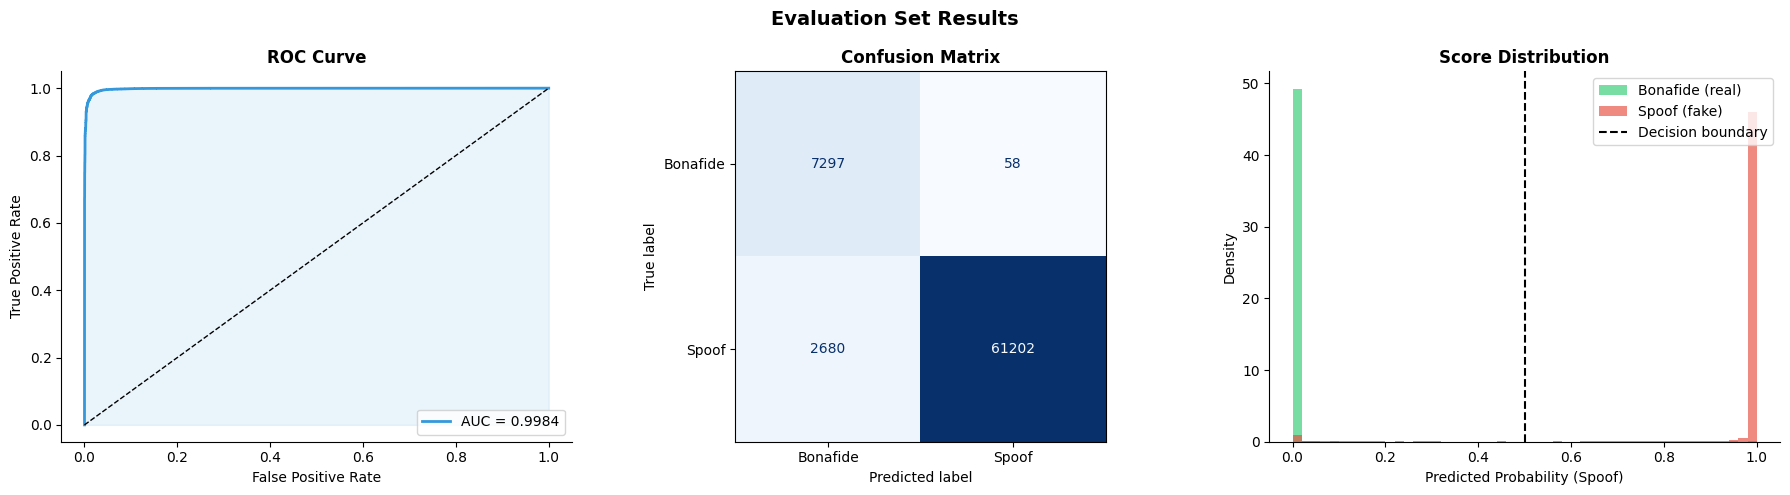

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Evaluation Set Results", fontsize=14, fontweight="bold")

# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, all_scores)
axes[0].plot(fpr, tpr, color="#3498db", lw=2,
             label=f"AUC = {final_auc:.4f}")
axes[0].plot([0,1],[0,1], "k--", lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#3498db")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].spines[["top","right"]].set_visible(False)

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Bonafide", "Spoof"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# ── Score Distribution ───────────────────────────────────────────────────────
real_scores  = all_scores[all_labels == 0]
spoof_scores = all_scores[all_labels == 1]
axes[2].hist(real_scores,  bins=50, alpha=0.65, color="#2ecc71",
             label="Bonafide (real)", density=True)
axes[2].hist(spoof_scores, bins=50, alpha=0.65, color="#e74c3c",
             label="Spoof (fake)",    density=True)
axes[2].axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Decision boundary")
axes[2].set_title("Score Distribution", fontweight="bold")
axes[2].set_xlabel("Predicted Probability (Spoof)")
axes[2].set_ylabel("Density")
axes[2].legend(); axes[2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/eval_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Attention Weight Visualization (Step 3 Demo)

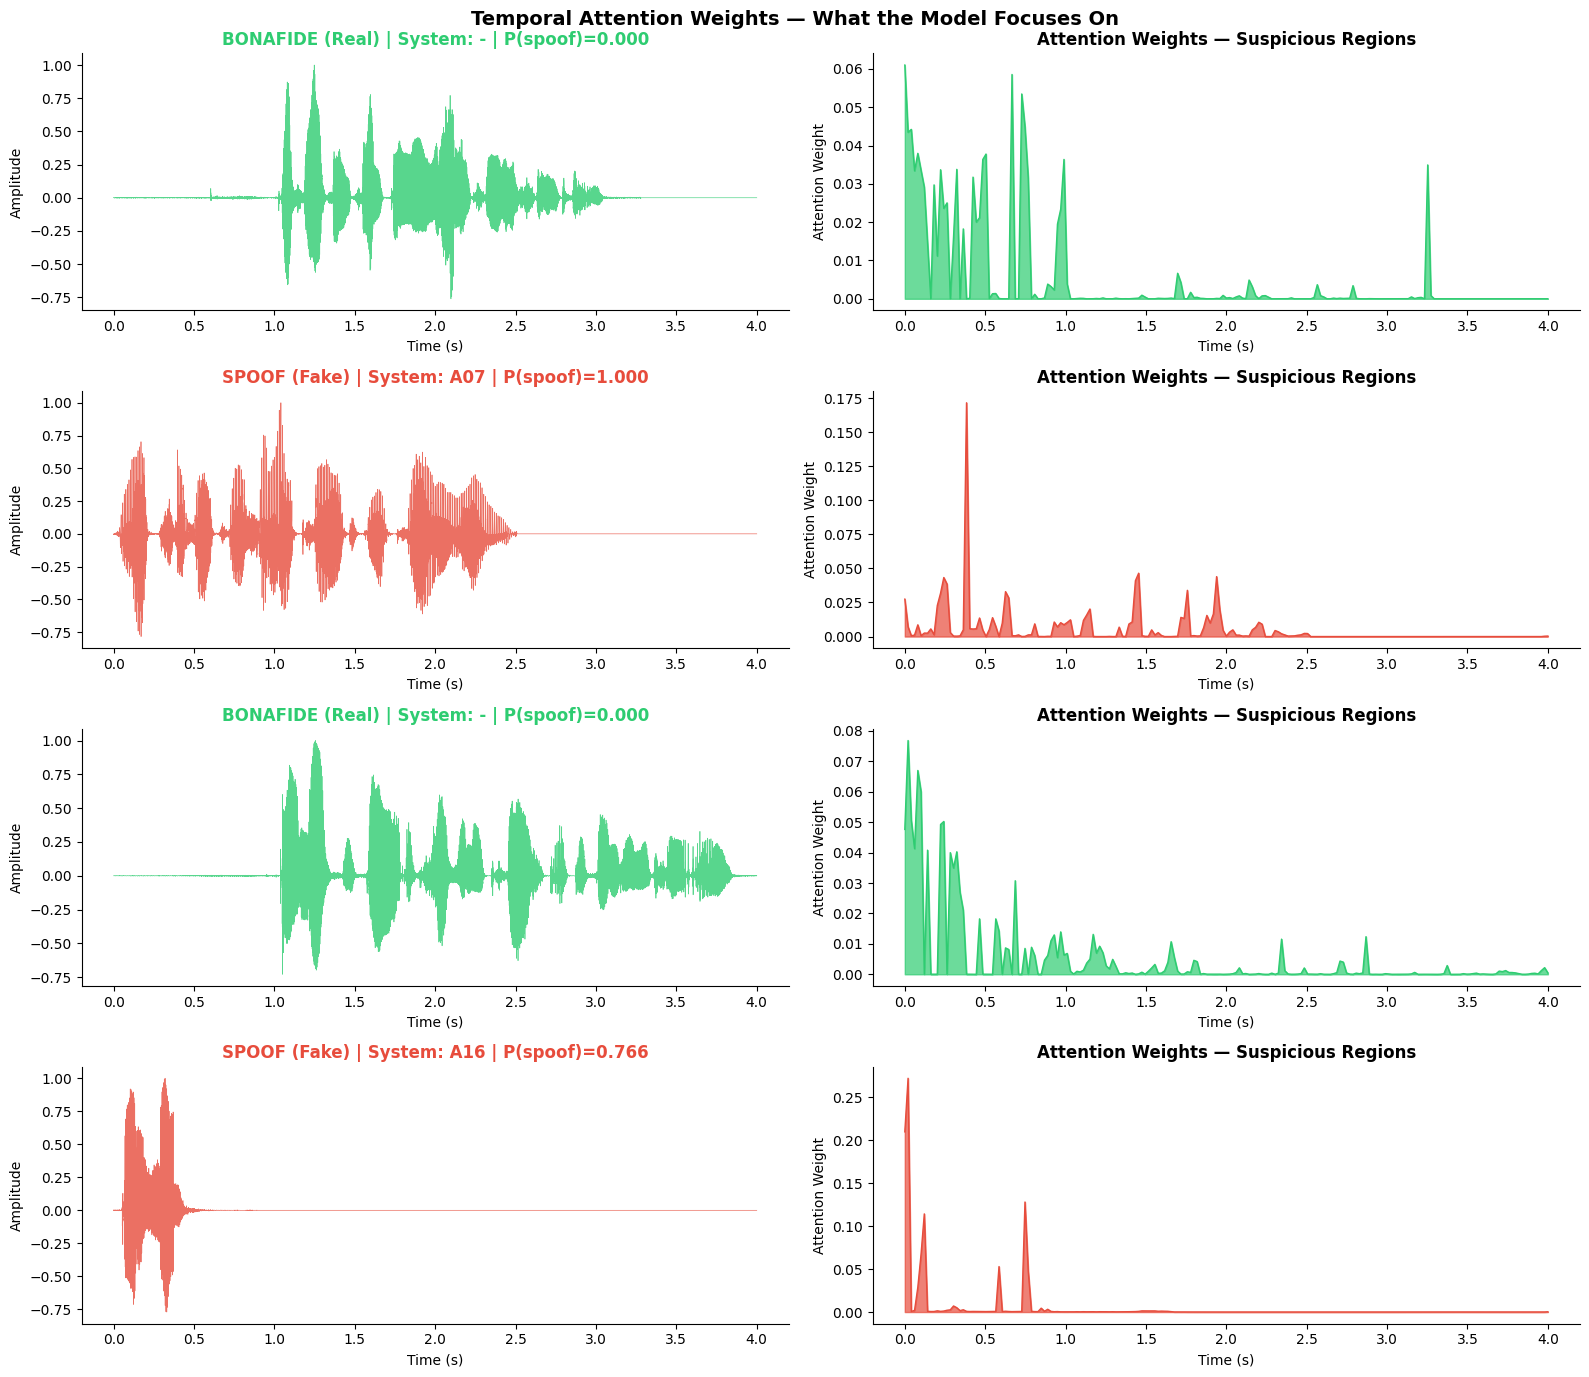

In [59]:
def plot_attention_heatmap(model, processor, audio_dir, df, n_samples=4, label_filter=None):
    """
    Show which time segments the model focuses on.
    This is your demo visualization for Step 3.
    """
    model.eval()
    core = model.module if isinstance(model, nn.DataParallel) else model

    sample_df = df if label_filter is None else df[df.label == label_filter]
    sample_df = sample_df.sample(n=n_samples, random_state=SEED).reset_index(drop=True)

    fig, axes = plt.subplots(n_samples, 2, figsize=(16, 3.5 * n_samples))
    fig.suptitle("Temporal Attention Weights — What the Model Focuses On",
                 fontsize=14, fontweight="bold")

    for i, row in sample_df.iterrows():
        path = os.path.join(audio_dir, row["file"] + ".flac")
        wav, sr = torchaudio.load(path)
        wav = wav.squeeze(0)
        if sr != 16000:
            wav = T.Resample(sr, 16000)(wav.unsqueeze(0)).squeeze(0)
        if wav.shape[0] < MAX_LEN:
            wav = F.pad(wav, (0, MAX_LEN - wav.shape[0]))
        else:
            wav = wav[:MAX_LEN]

        inp = processor(wav.numpy(), sampling_rate=16000,
                        return_tensors="pt", padding=False)
        with torch.no_grad():
            logit, attn = core(inp.input_values.to(DEVICE))
        prob  = torch.sigmoid(logit).item()
        attn  = attn.squeeze(0).cpu().numpy()  # [T']

        label_str = "SPOOF (Fake)" if row["label"] == 1 else "BONAFIDE (Real)"
        color     = "#e74c3c" if row["label"] == 1 else "#2ecc71"

        # Waveform
        t_wave = np.linspace(0, CFG["max_audio_len_sec"], len(wav))
        axes[i, 0].plot(t_wave, wav.numpy(), color=color, linewidth=0.5, alpha=0.8)
        axes[i, 0].set_title(f"{label_str} | System: {row['system']} | P(spoof)={prob:.3f}",
                              color=color, fontweight="bold")
        axes[i, 0].set_xlabel("Time (s)"); axes[i, 0].set_ylabel("Amplitude")
        axes[i, 0].spines[["top","right"]].set_visible(False)

        # Attention heatmap
        t_attn = np.linspace(0, CFG["max_audio_len_sec"], len(attn))
        axes[i, 1].fill_between(t_attn, attn, alpha=0.7, color=color)
        axes[i, 1].plot(t_attn, attn, color=color, linewidth=1)
        axes[i, 1].set_title("Attention Weights — Suspicious Regions",
                              fontweight="bold")
        axes[i, 1].set_xlabel("Time (s)"); axes[i, 1].set_ylabel("Attention Weight")
        axes[i, 1].spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/attention_heatmaps.png", dpi=150, bbox_inches="tight")
    plt.show()


# Mix of real and spoof samples
mixed_df = pd.concat([
    eval_df[eval_df.label==0].sample(2, random_state=SEED),
    eval_df[eval_df.label==1].sample(2, random_state=SEED)
]).reset_index(drop=True)

plot_attention_heatmap(model, processor, eval_audio, mixed_df, n_samples=4)

## 11. Save Weights + Config Locally

In [60]:
SAVE_DIR = f"{CFG['output_dir']}/model"
os.makedirs(SAVE_DIR, exist_ok=True)

core = model.module if isinstance(model, nn.DataParallel) else model

# 1. PyTorch weights
torch.save(core.state_dict(), f"{SAVE_DIR}/wav2vec2_classifier.pth")

# 2. Config JSON — needed to reconstruct model on inference
model_config = {
    "wav2vec2_name" : CFG["wav2vec_model"],
    "hidden_dim"    : CFG["hidden_dim"],
    "attn_dim"      : CFG["attn_dim"],
    "dropout"       : CFG["dropout"],
    "sample_rate"   : CFG["sample_rate"],
    "max_audio_len" : CFG["max_audio_len_sec"],
    "final_eer"     : round(final_eer * 100, 4),
    "final_auc"     : round(final_auc, 4),
    "final_acc"     : round(final_acc * 100, 4),
    "description"   : "Wav2Vec2-base + Temporal Attention + Classifier Head for deepfake voice detection",
    "dataset"       : "ASVspoof 2019 LA",
    "maps_to"       : "src/models/custom/",
}
with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(model_config, f, indent=2)

# 3. Model card README
readme_content = f"""# Deepfake Voice Detection — Wav2Vec2 Custom Branch

## Architecture
- **Encoder**: `{CFG['wav2vec_model']}` (last 3 layers fine-tuned)
- **Pooling**: Temporal Attention Pooling (learnable, visualizable)
- **Head**: LayerNorm → Linear(768→256) → GELU → Dropout → Linear(256→128) → Linear(128→1)

## Training
- **Dataset**: ASVspoof 2019 LA
- **Phase 1**: Frozen encoder, head only ({CFG['epochs_phase1']} epochs)
- **Phase 2**: Fine-tune last 3 transformer layers ({CFG['epochs_phase2']} epochs)

## Results (Eval Set)
| Metric | Value |
|--------|-------|
| EER | {final_eer*100:.2f}% |
| AUC | {final_auc:.4f} |
| Accuracy | {final_acc*100:.2f}% |

## Usage
```python
import torch, json
from transformers import Wav2Vec2Processor
# Load config
cfg = json.load(open("config.json"))
# Reconstruct model
model = Wav2Vec2Classifier(**{{k: cfg[k] for k in
    ['wav2vec2_name','hidden_dim','attn_dim','dropout']}},
    freeze_encoder=False)
model.load_state_dict(torch.load("wav2vec2_classifier.pth", map_location="cpu"))
model.eval()
```

## Maps to
`src/models/custom/` in the Deepfake Voice Detection project
"""
with open(f"{SAVE_DIR}/README.md", "w") as f:
    f.write(readme_content)

print("Local save complete ✓")
print(f"Files in {SAVE_DIR}:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f"{SAVE_DIR}/{f}") / 1e6
    print(f"  {f}  ({size:.1f} MB)")

Local save complete ✓
Files in /kaggle/working/outputs/model:
  wav2vec2_classifier.pth  (378.9 MB)
  README.md  (0.0 MB)
  config.json  (0.0 MB)


## 12. Push to HuggingFace Hub
> Make sure `HF_TOKEN` and `HF_REPO_ID` are set correctly in Cell 3

In [61]:
# ── Login ─────────────────────────────────────────────────────────────────────
login(token=HF_TOKEN)

# ── Create repo if it doesn't exist ──────────────────────────────────────────
api = HfApi()
try:
    create_repo(HF_REPO_ID, token=HF_TOKEN, private=False, exist_ok=True)
    print(f"Repo ready: https://huggingface.co/{HF_REPO_ID}")
except Exception as e:
    print(f"Repo note: {e}")

# ── Upload all model files ────────────────────────────────────────────────────
files_to_upload = [
    (f"{SAVE_DIR}/wav2vec2_classifier.pth",  "wav2vec2_classifier.pth"),
    (f"{SAVE_DIR}/config.json",              "config.json"),
    (f"{SAVE_DIR}/README.md",                "README.md"),
]

# Upload graphs too
graphs = [
    (f"{CFG['output_dir']}/training_dashboard.png", "graphs/training_dashboard.png"),
    (f"{CFG['output_dir']}/eval_results.png",       "graphs/eval_results.png"),
    (f"{CFG['output_dir']}/attention_heatmaps.png",  "graphs/attention_heatmaps.png"),
    (f"{CFG['output_dir']}/class_distribution.png", "graphs/class_distribution.png"),
    (f"{CFG['output_dir']}/spoof_systems.png",       "graphs/spoof_systems.png"),
]

for local_path, repo_path in files_to_upload + graphs:
    if os.path.exists(local_path):
        api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = repo_path,
            repo_id         = HF_REPO_ID,
            token           = HF_TOKEN,
        )
        print(f"  ✓ Uploaded: {repo_path}")

print(f"\n🎉 All files uploaded to https://huggingface.co/{HF_REPO_ID}")

Repo ready: https://huggingface.co/IshatShivhare/deepfake-voice-wav2vec2


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✓ Uploaded: wav2vec2_classifier.pth
  ✓ Uploaded: config.json


/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:9786: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


...

New Data Upload: |          |  0.00B /  0.00B            

  ✓ Uploaded: graphs/eval_results.png


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✓ Uploaded: graphs/attention_heatmaps.png
  ✓ Uploaded: graphs/class_distribution.png
  ✓ Uploaded: graphs/spoof_systems.png

🎉 All files uploaded to https://huggingface.co/IshatShivhare/deepfake-voice-wav2vec2


## 13. Quick Inference Test (Sanity Check)

In [62]:
def predict_file(audio_path, model, processor, device=DEVICE):
    """
    Run inference on a single audio file.
    Returns: probability of being spoof, attention weights
    """
    core = model.module if isinstance(model, nn.DataParallel) else model
    core.eval()

    wav, sr = torchaudio.load(audio_path)
    wav = wav.squeeze(0)
    if sr != 16000:
        wav = T.Resample(sr, 16000)(wav.unsqueeze(0)).squeeze(0)
    if wav.shape[0] < MAX_LEN:
        wav = F.pad(wav, (0, MAX_LEN - wav.shape[0]))
    else:
        wav = wav[:MAX_LEN]

    inp = processor(wav.numpy(), sampling_rate=16000,
                    return_tensors="pt", padding=False)
    with torch.no_grad():
        logit, attn = core(inp.input_values.to(device))

    prob = torch.sigmoid(logit).item()
    verdict = "🔴 SPOOF (Fake)" if prob > 0.5 else "🟢 BONAFIDE (Real)"
    print(f"File    : {os.path.basename(audio_path)}")
    print(f"P(spoof): {prob:.4f}")
    print(f"Verdict : {verdict}")
    return prob, attn.cpu().numpy()


# Test on one real and one spoof sample from eval set
real_sample  = eval_df[eval_df.label==0].iloc[0]["file"]
spoof_sample = eval_df[eval_df.label==1].iloc[0]["file"]

print("--- Real sample ---")
predict_file(os.path.join(eval_audio, real_sample + ".flac"), model, processor)
print()
print("--- Spoof sample ---")
predict_file(os.path.join(eval_audio, spoof_sample + ".flac"), model, processor)

--- Real sample ---
File    : LA_E_5849185.flac
P(spoof): 0.0000
Verdict : 🟢 BONAFIDE (Real)

--- Spoof sample ---
File    : LA_E_2834763.flac
P(spoof): 1.0000
Verdict : 🔴 SPOOF (Fake)


(1.0,
 array([[4.94668493e-03, 3.13708908e-04, 9.73913757e-06, 1.60524400e-03,
         2.42440891e-03, 1.72485865e-03, 1.19771517e-03, 2.75984267e-03,
         8.74859281e-03, 2.45640259e-02, 9.10042506e-03, 9.46957059e-03,
         1.05625222e-05, 1.81175656e-05, 1.26024978e-02, 7.22228959e-02,
         7.62734096e-04, 1.02277175e-01, 8.86650814e-05, 3.96526957e-06,
         1.12974030e-05, 1.13747281e-03, 2.07364163e-03, 3.55466567e-02,
         5.43516908e-05, 8.76147207e-03, 2.49271165e-04, 8.85376085e-06,
         2.76590767e-03, 2.33937870e-03, 2.61424831e-03, 7.56639987e-03,
         3.40348892e-02, 3.25103141e-02, 1.18812528e-02, 1.55527201e-02,
         4.27110195e-02, 1.21521279e-01, 4.34663612e-03, 6.55545965e-02,
         5.94631092e-06, 1.30451275e-02, 3.15509853e-03, 2.73257145e-03,
         3.11213825e-03, 8.60524457e-03, 1.77891488e-04, 9.49960486e-06,
         3.67958751e-03, 6.69059518e-05, 5.46530448e-03, 8.37165571e-04,
         1.08076572e-01, 1.14840500e-01, 2.03

**---
## Summary

| What was done | Where it maps |
|---|---|
| Pure PyTorch pipeline (Step 1) | Replaces `src/models/custom/` TF code |
| Wav2Vec2 encoder + classifier head (Step 2) | `src/models/custom/wav2vec2_classifier.py` |
| Temporal attention pooling (Step 3) | `src/models/custom/attention.py` |
| Phase 1: frozen encoder training | Transfer learning baseline |
| Phase 2: partial encoder fine-tuning | Improves generalization |
| Weights saved to HuggingFace Hub | `{HF_REPO_ID}` |
| Graphs: training dashboard, ROC, confusion matrix, attention heatmaps | `graphs/` in HF repo |